In [1]:
# ==========================================
# STEP 1 : IMPORT LIBRARIES
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score

In [2]:
# ==========================================
# STEP 2 : LOAD DATASET
# ==========================================

df = pd.read_csv("/content/Employee_Salary_Dataset (1).csv")

print("Dataset loaded successfully!")

df.head()

Dataset loaded successfully!


,ID,Experience_Years,Age,Gender,Salary
0,1,5,28,Female,250000
1,2,1,21,Male,50000
2,3,3,23,Female,170000
3,4,2,22,Male,25000
4,5,1,17,Male,10000


In [3]:
# ==========================================
# STEP 3 : EXPLORE DATASET
# ==========================================

print("Shape of Dataset:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nDataset Information:")
df.info()

print("\nStatistical Summary:")
print(df.describe())

Shape of Dataset:
(35, 5)

Column Names:
Index(['ID', 'Experience_Years', 'Age', 'Gender', 'Salary'], dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35 entries, 0 to 34
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   ID                35 non-null     int64 
 1   Experience_Years  35 non-null     int64 
 2   Age               35 non-null     int64 
 3   Gender            35 non-null     object
 4   Salary            35 non-null     int64 
dtypes: int64(4), object(1)
memory usage: 1.5+ KB

Statistical Summary:
              ID  Experience_Years        Age        Salary
count  35.000000          35.00000  35.000000  3.500000e+01
mean   18.000000           9.20000  35.485714  2.059147e+06
std    10.246951           7.55295  14.643552  3.170124e+06
min     1.000000           1.00000  17.000000  3.000000e+03
25%     9.500000           2.50000  22.500000  2.250000e+04
50% 

In [4]:
# ==========================================
# STEP 4 : CHECK MISSING VALUES
# ==========================================

print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
ID                  0
Experience_Years    0
Age                 0
Gender              0
Salary              0
dtype: int64


In [5]:
# ==========================================
# STEP 5 : SELECT INPUT AND TARGET
# ==========================================

# Input feature
X = df[["Experience_Years"]]

# Target variable
y = df[["Salary"]]

print("Input X:")
print(X.head())

print("\nTarget y:")
print(y.head())

Input X:
   Experience_Years
0                 5
1                 1
2                 3
3                 2
4                 1

Target y:
   Salary
0  250000
1   50000
2  170000
3   25000
4   10000


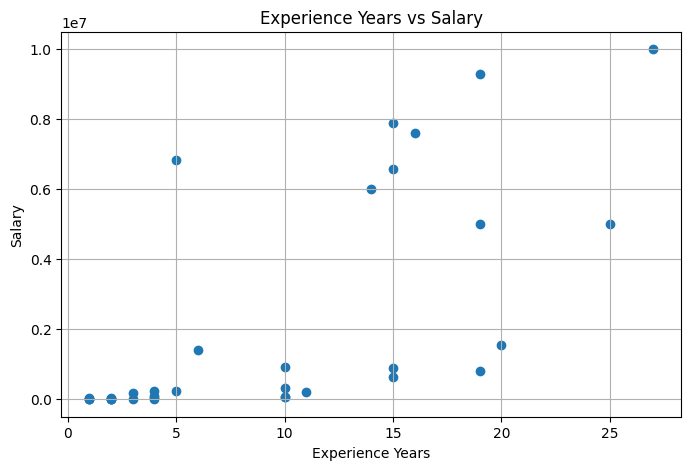

In [6]:
# ==========================================
# STEP 6 : VISUALIZE ORIGINAL DATA
# ==========================================

plt.figure(figsize=(8, 5))

plt.scatter(
    df["Experience_Years"],
    df["Salary"]
)

plt.xlabel("Experience Years")
plt.ylabel("Salary")
plt.title("Experience Years vs Salary")

plt.grid(True)

plt.show()

In [7]:
# ==========================================
# STEP 7 : TRAIN-TEST SPLIT
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data size:", X_train.shape)
print("Testing data size :", X_test.shape)

Training data size: (28, 1)
Testing data size : (7, 1)


In [8]:
# ==========================================
# STEP 8 : CONVERT DATA TO PYTORCH TENSORS
# ==========================================

X_train = torch.tensor(
    X_train.values,
    dtype=torch.float32
)

X_test = torch.tensor(
    X_test.values,
    dtype=torch.float32
)

y_train = torch.tensor(
    y_train.values,
    dtype=torch.float32
)

y_test = torch.tensor(
    y_test.values,
    dtype=torch.float32
)

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)

print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)

X_train shape: torch.Size([28, 1])
X_test shape : torch.Size([7, 1])
y_train shape: torch.Size([28, 1])
y_test shape : torch.Size([7, 1])


In [9]:
# ==========================================
# STEP 9 : BUILD LINEAR REGRESSION MODEL
# ==========================================

class LinearRegressionModel(nn.Module):

    def __init__(self):
        super().__init__()

        self.linear = nn.Linear(1, 1)

    def forward(self, x):
        return self.linear(x)


model = LinearRegressionModel()

print(model)

LinearRegressionModel(
  (linear): Linear(in_features=1, out_features=1, bias=True)
)


In [10]:
# ==========================================
# STEP 10 : DEFINE LOSS FUNCTION
# ==========================================

criterion = nn.MSELoss()

print("Loss Function:")
print(criterion)

Loss Function:
MSELoss()


In [11]:
# ==========================================
# STEP 11 : DEFINE OPTIMIZER
# ==========================================

optimizer = optim.Adam(
    model.parameters(),
    lr=0.01
)

print("Optimizer:")
print(optimizer)

Optimizer:
Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.01
    maximize: False
    weight_decay: 0
)


In [12]:
# ==========================================
# STEP 12 : TRAIN THE MODEL
# ==========================================

epochs = 1000

loss_history = []

for epoch in range(epochs):

    # Forward pass
    predictions = model(X_train)

    # Calculate loss
    loss = criterion(predictions, y_train)

    # Clear previous gradients
    optimizer.zero_grad()

    # Backward pass
    loss.backward()

    # Update weights and bias
    optimizer.step()

    # Store loss
    loss_history.append(loss.item())

    # Print loss every 100 epochs
    if (epoch + 1) % 100 == 0:
        print(
            f"Epoch [{epoch + 1}/{epochs}], "
            f"Loss: {loss.item():.4f}"
        )

Epoch [100/1000], Loss: 17497299353600.0000
Epoch [200/1000], Loss: 17497207078912.0000
Epoch [300/1000], Loss: 17497115852800.0000
Epoch [400/1000], Loss: 17497022529536.0000
Epoch [500/1000], Loss: 17496932352000.0000
Epoch [600/1000], Loss: 17496839028736.0000
Epoch [700/1000], Loss: 17496748851200.0000
Epoch [800/1000], Loss: 17496655527936.0000
Epoch [900/1000], Loss: 17496565350400.0000
Epoch [1000/1000], Loss: 17496473075712.0000


In [13]:
# ==========================================
# STEP 13 : DISPLAY LEARNED WEIGHT AND BIAS
# ==========================================

weight = model.linear.weight.item()
bias = model.linear.bias.item()

print("Learned Weight:", weight)
print("Learned Bias  :", bias)

Learned Weight: 9.839351654052734
Learned Bias  : 10.673523902893066


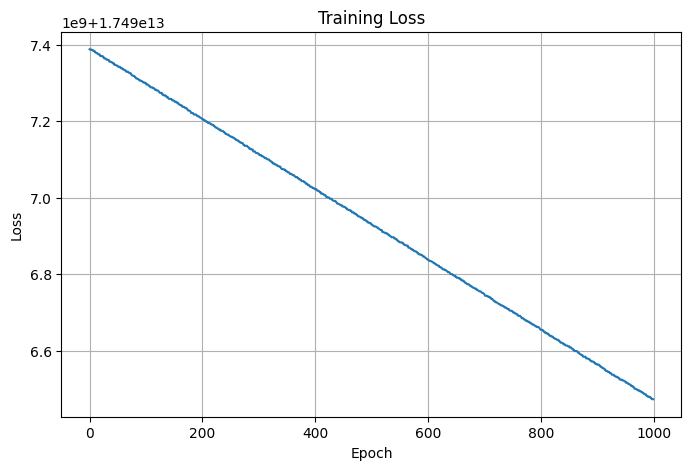

In [14]:
# ==========================================
# STEP 14 : PLOT TRAINING LOSS
# ==========================================

plt.figure(figsize=(8, 5))

plt.plot(loss_history)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")

plt.grid(True)

plt.show()

In [15]:
# ==========================================
# STEP 15 : MAKE PREDICTIONS
# ==========================================

model.eval()

with torch.no_grad():

    y_pred = model(X_test)

print("Predicted Salaries:")
print(y_pred[:10])

Predicted Salaries:
tensor([[ 20.5129],
        [118.9064],
        [ 50.0309],
        [ 50.0309],
        [ 50.0309],
        [ 30.3522],
        [109.0670]])


In [16]:
# ==========================================
# STEP 16 : COMPARE ACTUAL AND PREDICTED
# ==========================================

print("Actual Salary      Predicted Salary")

for actual, predicted in zip(y_test[:10], y_pred[:10]):

    print(
        f"{actual.item():.2f}"
        f"          "
        f"{predicted.item():.2f}"
    )

Actual Salary      Predicted Salary
3000.00          20.51
220100.00          118.91
8900.00          50.03
25000.00          50.03
87000.00          50.03
6100.00          30.35
330000.00          109.07


In [17]:
# ==========================================
# STEP 17 : EVALUATE THE MODEL
# ==========================================

# Convert tensors to NumPy
y_test_numpy = y_test.numpy()
y_pred_numpy = y_pred.numpy()

# Mean Squared Error
mse = mean_squared_error(
    y_test_numpy,
    y_pred_numpy
)

# Mean Absolute Error
mae = mean_absolute_error(
    y_test_numpy,
    y_pred_numpy
)

# R2 Score
r2 = r2_score(
    y_test_numpy,
    y_pred_numpy
)

print("Model Evaluation")
print("----------------------------")

print("Mean Squared Error :", mse)
print("Mean Absolute Error:", mae)
print("R2 Score           :", r2)

Model Evaluation
----------------------------
Mean Squared Error : 23646650368.0
Mean Absolute Error: 97095.875
R2 Score           : -0.6621326208114624


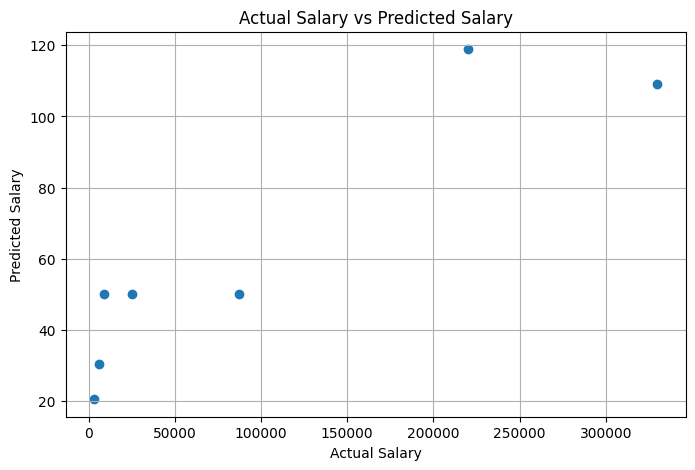

In [18]:
# ==========================================
# STEP 18 : ACTUAL VS PREDICTED GRAPH
# ==========================================

plt.figure(figsize=(8, 5))

plt.scatter(
    y_test_numpy,
    y_pred_numpy
)

plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")

plt.title("Actual Salary vs Predicted Salary")

plt.grid(True)

plt.show()

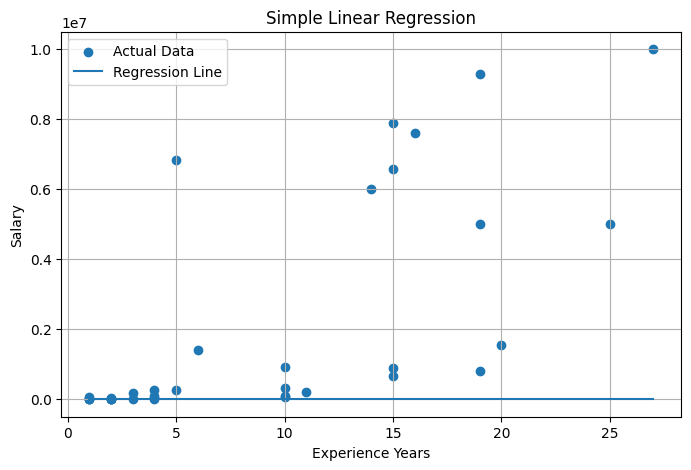

In [19]:
# ==========================================
# STEP 19 : REGRESSION LINE
# ==========================================

plt.figure(figsize=(8, 5))

# Plot actual data
plt.scatter(
    df["Experience_Years"],
    df["Salary"],
    label="Actual Data"
)

# Create x values for the line
x_line = np.linspace(
    df["Experience_Years"].min(),
    df["Experience_Years"].max(),
    100
)

# Calculate predicted y values
y_line = weight * x_line + bias

# Plot regression line
plt.plot(
    x_line,
    y_line,
    label="Regression Line"
)

plt.xlabel("Experience Years")
plt.ylabel("Salary")

plt.title("Simple Linear Regression")

plt.legend()

plt.grid(True)

plt.show()

In [20]:
# ==========================================
# STEP 20 : PREDICT NEW SALARY
# ==========================================

new_experience = torch.tensor(
    [[10.0]],
    dtype=torch.float32
)

model.eval()

with torch.no_grad():

    predicted_salary = model(new_experience)

print(
    "Predicted Salary for 10 Years Experience:",
    predicted_salary.item()
)

Predicted Salary for 10 Years Experience: 109.0670394897461


In [ ]:
# ==========================================
# STEP 21 : CONCLUSION
# ==========================================

print("""
CONCLUSION
==========

A Simple Linear Regression model was successfully
implemented using PyTorch on the Employee Salary dataset.

Experience_Years was used as the input feature and
Salary was used as the target variable.

The dataset was loaded, checked for missing values,
split into training and testing data, and converted
into PyTorch tensors.

A linear regression model was created using
nn.Linear(1,1). Mean Squared Error was used as the
loss function and Adam was used as the optimizer.

The model was trained using forward propagation,
backpropagation and parameter updates.

The model was evaluated using MSE, MAE and R2 Score.
The training loss graph and regression line were also
used to visualize the results.

The observations show a relationship between experience
and salary, and the trained model can be used to predict
salary from years of experience.
""")